# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [45]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [46]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [47]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [48]:
# mostrar las primeras 5 filas de users
users.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [49]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [50]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [51]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [52]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [53]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [54]:
# cantidad de nulos para users


proporcion_nulos = users.isnull().mean()
print("proporción de valores nulos del dataset users: ", proporcion_nulos)    # Cantidad de valores nulos)
porcentaje_nulos = users.isnull().mean() * 100
# print(# Cantidad de valores nulos)
print("porcentaje de valores nulos del dataset users: ", porcentaje_nulos)   # Proporción de valores nulos)



proporción de valores nulos del dataset users:  user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64
porcentaje de valores nulos del dataset users:  user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [55]:
# cantidad de nulos para usage
proporcion_nulos = usage.isnull().mean()
print("proporción de valores nulos del dataset usage: ", proporcion_nulos)    # Cantidad de valores nulos)
porcentaje_nulos = usage.isnull().mean() * 100
# print(# Cantidad de valores nulos)
print("porcentaje de valores nulos del dataset usage: ", porcentaje_nulos)   # Proporción de valores nulos)


proporción de valores nulos del dataset usage:  id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64
porcentaje de valores nulos del dataset usage:  id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Indica qué harías: ¿imputar, eliminar, ignorar?

DIAGNOSTICO:
1. En el dataset "users" la columna -->	city tiene un 11.72% de nulos. Aquí se recomiemda investigar/imputar; ya que  al ser >5% pero <30%, se debe revisar si hay relación con otras variables antes de decidir si se imputa con "Desconocido" o se ignora.
2. En el dataset "users" la columna -->	churn_date	tiene un 88.35%	de nulos. Aquí se recomienda ignorar; ya que la alta proporción indica que el cliente sigue activo; no se elimina la columna porque su ausencia es un dato en sí mismo que significa que el cliente está vigente.
3. En el dataset "usage" la columna -->	date	tiene un 0.12%	de nulos. La recomendación puede ser Eliminar/Imputar, ya que al ser menor al 5%, se pueden eliminar esas filas o imputar con la fecha más frecuente sin sesgar el análisis.
4. En el dataset "usage" la columna -->	duration tiene un 55.19% de nulos. En este caso se puede Ignorar (MAR), ya que los nulos dependen del type. Si el registro es un mensaje ("text"), no tiene duración de llamada; se mantienen para análisis de mensajes.
5. En el dataset "users" la columna -->	length tiene un 44.74% de nulos. Aquí se puede Ignorar (MAR), ya que es similar al dato de duration; si el registro es una llamada ("call"), no tiene longitud de caracteres; se mantienen para análisis de llamadas.

 Justificación de Decisiones

-- En users (churn_date): Los valores nulos son informativos (significan "usuario activo"), por lo que eliminarlos o imputarlos sería un error conceptual.

--  En usage (duration y length): Estamos ante valores perdidos al azar (MAR - Missing At Random). La columna type explica perfectamente el nulo: los mensajes no duran minutos y las llamadas no tienen longitud de texto. No se deben eliminar ni imputar con la media, pues contaminarían las métricas del otro servicio.

  -- En users (city): Al ser una variable categórica relevante para la segmentación geográfica, se recomienda marcar los nulos como "No especificado" para no perder los datos de uso asociados a esos user_id.



### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [56]:
# explorar columnas numéricas de users
print(users[['user_id']].describe())
print(users[['age']].describe())

            user_id
count   4000.000000
mean   11999.500000
std     1154.844867
min    10000.000000
25%    10999.750000
50%    11999.500000
75%    12999.250000
max    13999.000000
               age
count  4000.000000
mean     33.739750
std     123.232257
min    -999.000000
25%      32.000000
50%      47.000000
75%      63.000000
max      79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
  En esta columna podemos se observa que la clave de "user_id" es un valor secuencial que inicia en el 10000 y termina en el valor 13999 (4000 registros); se puede concluir que esta columna contiene puros valores válidos.
- La columna `age` ...
  En esta columna se puede deducir que existen outliers y posiblemente valores inválidos, tal como el valor mínimo de "-999", razón por la cual hay que analizar con mayor detalle los valores a fin de determinar las acciones a seguir.

In [57]:
# explorar columnas numéricas de usage
print(usage[['id']].describe())
print(usage[['user_id']].describe())

                id
count  40000.00000
mean   20000.50000
std    11547.14972
min        1.00000
25%    10000.75000
50%    20000.50000
75%    30000.25000
max    40000.00000
            user_id
count  40000.000000
mean   12002.405975
std     1157.279564
min    10000.000000
25%    10996.000000
50%    12013.000000
75%    13005.000000
max    13999.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
  En la columna "id"  se observa que esta clave  es un valor secuencial que inicia en el 1 y termina en el valor 4000 y los quartiles coinciden con 1000, 2000 y 3000, pór lo cual puedo concluir que esta columna contiene puros valores válidos.
  En cuanto a la columna "user_id" se abserva que los valores de este dato van desde el mínimo de 1000 hasta el máximo de 13999, lo cual nos indica que contiene puros valores correctos, además de que el promedio parece estar cerca del vaalor intermedio, lo cual da señaales de que puede ser congruente; la desviación estándar aunque parece amplia, habría que estar sujeta a un mayor análisis.

In [58]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"--- Exploración de la columna: {col} ---")
    
    # Conteo de valores (Frecuencia absoluta)
    conteo = users[col].value_counts(dropna=False)
    
    # Proporción (Frecuencia relativa en porcentaje)
    proporcion = users[col].value_counts(normalize=True, dropna=False) * 100
    
    # Combinamos ambos en un DataFrame para mejor lectura
    resumen = pd.DataFrame({'Frecuencia': conteo, 'Porcentaje (%)': proporcion})
    print(resumen)
    print(f"Valores únicos en {col}: {users[col].nunique()}")
    print(f"Valores nulos en {col}: {users[col].isnull().sum()}")
    print(users[{col}].describe())
    print("\n")



--- Exploración de la columna: city ---
          Frecuencia  Porcentaje (%)
Bogotá           808          20.200
CDMX             730          18.250
Medellín         616          15.400
NaN              469          11.725
GDL              450          11.250
Cali             424          10.600
MTY              407          10.175
?                 96           2.400
Valores únicos en city: 7
Valores nulos en city: 469
          city
count     3531
unique       7
top     Bogotá
freq       808


--- Exploración de la columna: plan ---
         Frecuencia  Porcentaje (%)
Basico         2595          64.875
Premium        1405          35.125
Valores únicos en plan: 2
Valores nulos en plan: 0
          plan
count     4000
unique       2
top     Basico
freq      2595




- La columna `city` ...
  Diagnóstico de la columna "city" (Ubicación Geográfica):
  Se detecta que tiene problemas de calidad de datos que puede ser un tanto crítico:
  - Existe presencia de "Sentinels": Se detectó el valor "?" en 96 registros (2.4%). Este es un valor "centinela" que representa datos mal capturados.
  - Existen valores Nulos Significativos: Hay 469 nulos reales (NaN), lo que equivale al 11.72%.
    Esto tiene el siguiente impacto: Sumando los "NaN" y los "?", tenemos un 14.12% de datos sin ubicación válida.
    Esto indica una debilidad en el proceso de registro de usuarios que debe corregirse.

  - Concentración de Mercado:
    El mercado se conccentra principalmente en dos países y es básicamente metropolitano: Bogotá (20.2%) y CDMX (18.25%) lideran la base de clientes.

  - Acción recomendada: Reemplazar los ? y NaN por una etiqueta como "No definida" para poder incluirlos en el análisis sin sesgar las estadísticas de las ciudades conocidas.

- La columna `plan` ...
  Diagnóstico de la columna "plan" (estructura comercial):
  Integridad de los Datos: Esta columna está 100% limpia; no hay nulos ni valores extraños. Esto es positivo, ya que es la variable que determina los ingresos (facturación).
  Preferencia de Producto: Existe una clara dominancia del Plan Básico (64.8%) sobre el Premium (35.1%).
  Insight de Negocio: Casi 2 de cada 3 clientes prefieren el plan económico. Esto sugiere que el mercado es altamente sensible al precio o que los beneficios del plan Premium no están siendo lo suficientemente claros o atractivos para justificar el salto de costo.
 

In [59]:

# explorar columna categórica de usage
# usage['type'] # completa el código
print(usage[['type']].describe())


         type
count   40000
unique      2
top      text
freq    22092


- La columna `type` ...
  Esta columna tiene 40000 registros y no tiene valores nulos. El valor que más se repite es "text"; esto nos indica  que la mayoría de los registros de uso están asociados a servicios de mensajería de texto, pues "text" aparece en 22,092 registros (55.23%).
Existen solamente dos valores para "type", el otro valor es "call"; vemos que el dataset está relativamente balanceado, aunque con una ligera inclinación hacia los servicios de texto. No hay un desequilibrio extremo que pueda sesgar un modelo de predicción de comportamiento.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
  
  Conclusiones Generales y Próximos Pasos:

    Estandarización Necesaria: Antes de proceder al análisis de comportamiento de uso, es obligatorio limpiar la columna city convirtiendo los ? en nulos y luego decidiendo si se imputan o se marcan como "Sin Información".

    Oportunidad de Up-selling: Con un 65% de usuarios en el plan Básico, el equipo de marketing tiene una oportunidad grande de migración de clientes hacia el Premium, especialmente en las ciudades principales (Bogotá y CDMX) donde la infraestructura suele soportar mejor el alto consumo de datos.

    Análisis de Uso: El siguiente paso es cruzar estos grupos (Ciudad y Plan) con el dataset de usage.csv para ver si los usuarios del plan Básico están excediendo sus límites, lo que validaría la necesidad de ofrecerles el cambio a Premium.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [60]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')    # completa el código

In [61]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')      # completa el código

In [62]:
# Revisar los años presentes en `reg_date` de users
print("Años en reg_date (users):")
print(users['reg_date'].dt.year.value_counts().sort_index())

Años en reg_date (users):
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En esta columna veo que en cada año el número de usuarios siempre es mayor ligeramente al año anterior.
Pero aparecen 40 registros del año 2026, lo cual es un error pues se supone que tenemos datos hasta el año 2024

In [63]:
# Revisar los años presentes en `date` de usage
print("\nAños en date (usage):")
print(usage['date'].dt.year.value_counts().sort_index())


Años en date (usage):
2024.0    39950
Name: date, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

En "usage" vemos qque solamente existe información para el año 2024, lo cual muestra uan inconsistencia contra el dataset de "users". Con este problema no es posible obtener información de comportamiento anual; solamente una información de la "foto" del año 2024.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

  DIAGNÓSTICO Y RECOMENDACIONES
  No hay años imposibles, pero existe una inconsistencia lógica con el dataset users. El dataset de "users" muestra personas registradas en 2022, 2023 y 2024 (más 40 regsitros de 2026), pero el dataset de "usage" solo tiene datos de 2024.  Con esta información solamente se puede obtener información sobre el año 2024.
  Hay que trabajar en el análisis y limpieza de datos de la información del año 2026. También es necesario revisar el proceso de carga del dataset "usage" para tratar de recuperar la información de los años 20222 y 2023.
  En cuanto a la informaación del año 2026, hay que analizar qué resulta más conveniente o pertinente, entre Corregir/Imputar, ya sea cambiar 2026 por 2024 (que es la moda) o dejar como nulo, ya que es un error de captura.
  

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [64]:
# Reemplazar -999 por la mediana de age
# Primero convertimos los -999 a NaN para que no afecten el cálculo de la mediana
users.loc[users['age'] == -999, 'age'] = np.nan
age_mediana = users['age'].median()   #...
users['age'] = users['age'].fillna(age_mediana)  #...

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [65]:
# Reemplazar ? por NA en city
# Usamos pd.NA que es el estándar más moderno de pandas para valores faltantes
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print("Cantidad de valores nulos en 'city':")
print(users['city'].isna().sum())

Cantidad de valores nulos en 'city':
565


In [66]:

# Marcar fechas futuras como NA para reg_date
# PASO 1: Asegurar que es tipo fecha (esto limpia cualquier error previo)
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# PASO 2: Aplicar la limpieza de fechas futuras
# Usamos el año 2024 como límite basado en tu diagnóstico
users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year <= 2024, pd.NA)

# PASO 3: ¡MUY IMPORTANTE! Volver a forzar el tipo datetime 
# Esto convierte los pd.NA en NaT (Not a Time), que es el nulo oficial de fechas
users['reg_date'] = pd.to_datetime(users['reg_date'])

# Verificar cambios 
print("Distribución de años en reg_date (post-limpieza):")
print(users['reg_date'].dt.year.value_counts().sort_index())
print(f"\nTotal de registros nulos en reg_date: {users['reg_date'].isna().sum()}")

Distribución de años en reg_date (post-limpieza):
2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64

Total de registros nulos en reg_date: 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [67]:
# Verificación MAR en usage (Missing At Random) para duration
# Agrupamos por el tipo de servicio y contamos cuántos nulos hay en cada métrica
nulos_por_tipo = usage.groupby('type')[['duration', 'length']].apply(lambda x: x.isnull().sum())

print("Distribución de nulos por tipo de servicio:")
print(nulos_por_tipo)

Distribución de nulos por tipo de servicio:
      duration  length
type                  
call         0   17896
text     22076       0


In [68]:
# Verificación MAR en usage (Missing At Random) para length


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Los datos son MAR de forma muy clara, ya que existe una dependencia absoluta y lógica entre la columna type y la presencia de nulos:
-- Para call: Hay 0 nulos en duration, lo cual es perfecto. Los 17,896 nulos en length son correctos, porque una llamada no tiene caracteres de texto.
-- Para text: Hay 0 nulos en length, indicando que todos los mensajes tienen contenido; los 22,076 nulos en duration son correctos, porque un mensaje de texto no tiene duración en segundos.

Podemos concluir que el sistema de registro de la empresa es muy bueno en esta parte, ya que no hay "fugas" de datos: no existen llamadas con duración 0 o nula (lo que indicaría llamadas caídas o errores de red). Asimismo, no hay errores de cruce: no hay mensajes de texto que accidentalmente tengan registrada una duración.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [69]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),      # Sumamos los 1s de la columna auxiliar
    cant_llamadas=("is_call", "sum"),      # Sumamos los 1s de la columna auxiliar
    cant_minutos_llamada=("duration", "sum") # Sumamos la duración total
).reset_index()

# Observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [70]:
# Renombrar columnas

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [71]:

# Combinar la tabla agregada (usage_agg) con el dataset de usuarios (users)
user_profile = pd.merge(users, usage_agg, on="user_id", how="left")

# IMPORTANTE: Los usuarios sin registros en 'usage' tendrán valores NaN en las métricas.
# Reemplazamos esos nulos con 0 para que el perfil sea estadísticamente correcto.
columnas_uso = ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
user_profile[columnas_uso] = user_profile[columnas_uso].fillna(0)

# Opcional: Convertir conteos a enteros para una visualización más limpia
user_profile[["cant_mensajes", "cant_llamadas"]] = user_profile[["cant_mensajes", "cant_llamadas"]].astype(int)

# Observar el perfil completo de los primeros 5 usuarios
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [72]:
# Resumen estadístico de las columnas numéricas
# Seleccionamos las columnas numéricas relevantes
cols_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Obtenemos el resumen estadístico descriptivo
resumen_num = user_profile[cols_numericas].describe()

# Agregamos la mediana específicamente (ya que describe() no la incluye por defecto, usa el percentil 50%)
print("Resumen estadístico de usuarios:")
display(resumen_num)

Resumen estadístico de usuarios:


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,5.523000,4.477000,23.311225
std,17.689919,2.359738,2.145139,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.412500
max,79.000000,17.000000,15.000000,155.690000


In [73]:
# Distribución porcentual del tipo de plan

# Para obtener la distribución porcentual de la columna plan, utilizaremos el método value_counts() con el parámetro normalize=True. Esto transformará las frecuencias absolutas en proporciones, que luego multiplicaremos por 100 para obtener el formato de porcentaje.
# 1. Calcular la distribución de frecuencias relativas (porcentajes)
plan_dist = user_profile['plan'].value_counts(normalize=True) * 100

# 2. Mostrar el resultado formateado
print("Distribución porcentual por tipo de plan:")
print(plan_dist.map("{:.2f}%".format))

# 3. Opcional: Ver la distribución con conteos reales al lado
plan_resumen = pd.DataFrame({
    'Cantidad': user_profile['plan'].value_counts(),
    'Porcentaje': plan_dist.map("{:.2f}%".format)
})
print("\nResumen comparativo:")
print(plan_resumen)

Distribución porcentual por tipo de plan:
Basico     64.88%
Premium    35.12%
Name: plan, dtype: object

Resumen comparativo:
         Cantidad Porcentaje
Basico       2595     64.88%
Premium      1405     35.12%


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

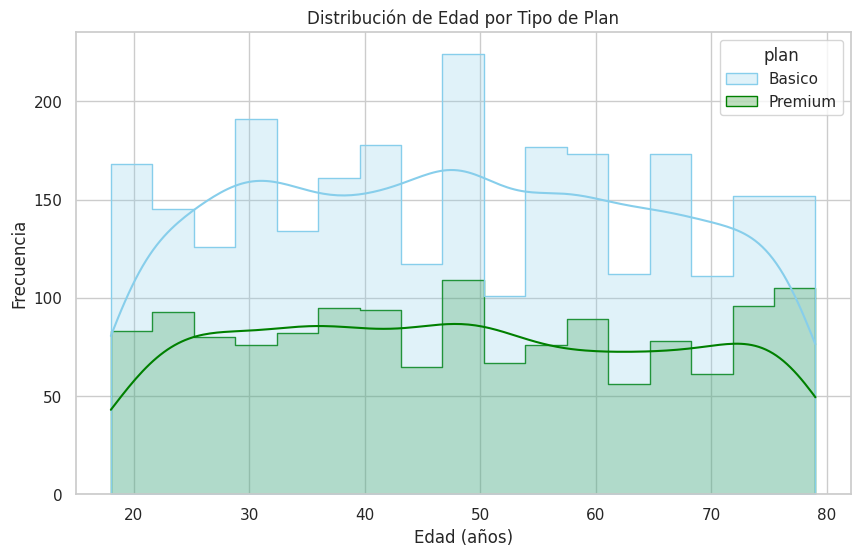

In [74]:
# Histograma para visualizar la edad (age)
sns.set_theme(style="whitegrid")
palette = {'Basico': 'skyblue', 'Premium': 'green'} # Ajusta los nombres exactos de los planes
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='age', hue='plan', palette=palette, kde=True, element="step")
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.show()

# sns.histplot(...)
# plt.show()

💡Insights: 
- Distribución ...
  La distribución es muy similar en ambos planes. No parece haber una segmentación de edad por plan; tanto jóvenes como adultos eligen indistintamente "Basico" o "Premium".
Asmismo, la distribución es simétrica y uniforme entre las edades de los 23 a los 70 años, teniendo un máximo (solo un poco mayor) entre los 48 y 50 años; en ambos planes empiezan a disminuir a partir de los 70 años  aproximadamente. 

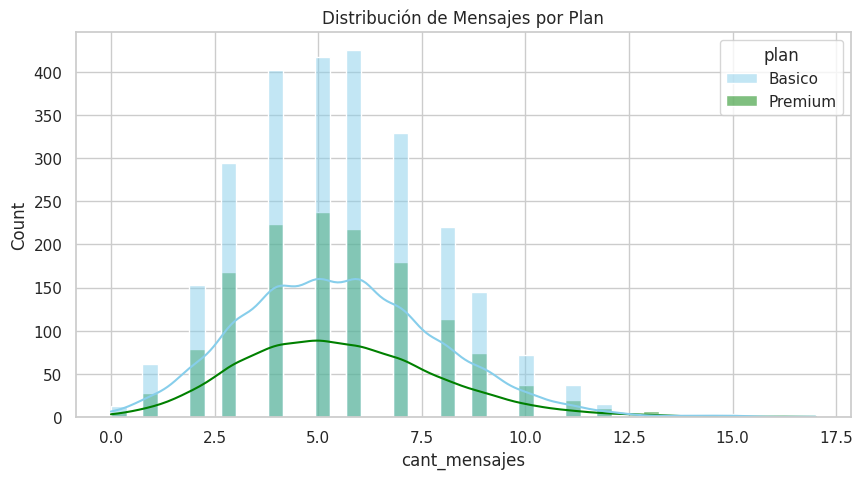

In [75]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette={'Basico': 'skyblue', 'Premium': 'green'}, kde=True)
plt.title('Distribución de Mensajes por Plan')
plt.show()

💡Insights: 
- Nuevamente se aprecian comportamientos similares entre lso dos tipos de planes, además de que se aprecia una distribución tipo "Normal" en ambas gráficas, donde la cantidad de manesajes mayor está entre 5 y 6. Obviamente existen pocas "colas" de pocos mensaajes menores a 1 minuto y mayores a 12 minutos, existiendo un ligero sesgo hacia la derecha en outliers de 15 y hasta 17.5 mensajes.

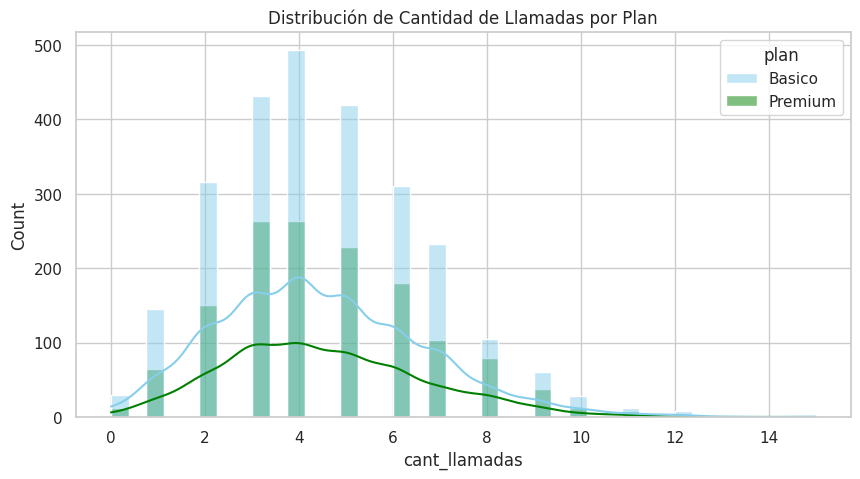

In [76]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette={'Basico': 'skyblue', 'Premium': 'green'}, kde=True)
plt.title('Distribución de Cantidad de Llamadas por Plan')
plt.show()

💡Insights: 
- Distribución ...
  En este caso también existe similitud entre ambos planes, y ambos tienen un máximo de 4 llamadas por plan, así como un sesgo hacia la derecha, llegando a tener casos excepcionales de 12 y 14 llamadas 

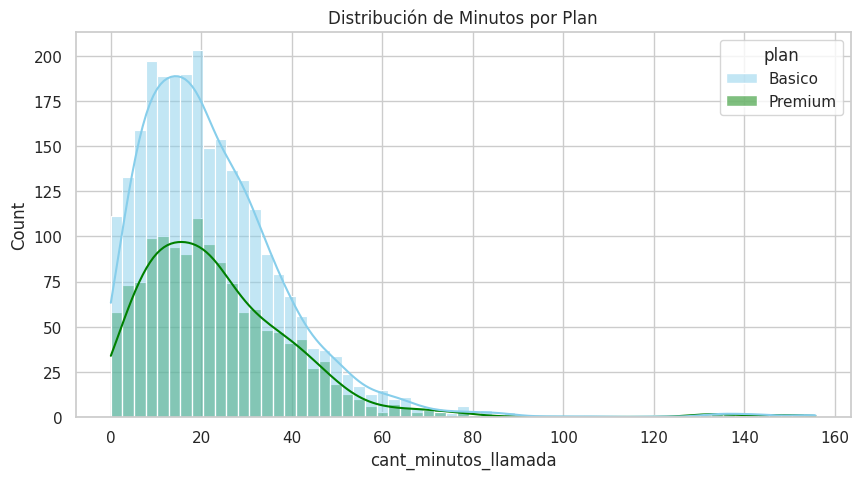

In [77]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette={'Basico': 'skyblue', 'Premium': 'green'}, kde=True)
plt.title('Distribución de Minutos por Plan')
plt.show()

💡Insights: 
- En este caso ambos planes presentan distribuciones semejantes tipo "chi cuadrada", en donde obviamente el plan premium tiene outliers que se alejan demasiado de los valores promedios y de la mediana, llegando a existir valores cercanos a 160 minutos. Dentro del plan Premium, hay una mayor proporción de usuarios que consumen más minutos (la curva verde es ligeramente más alta en la parte derecha que la azul). Los usuarios de plan Basico tienden a concentrarse más en el rango de 10-20 minutos para evitar cobros extra.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

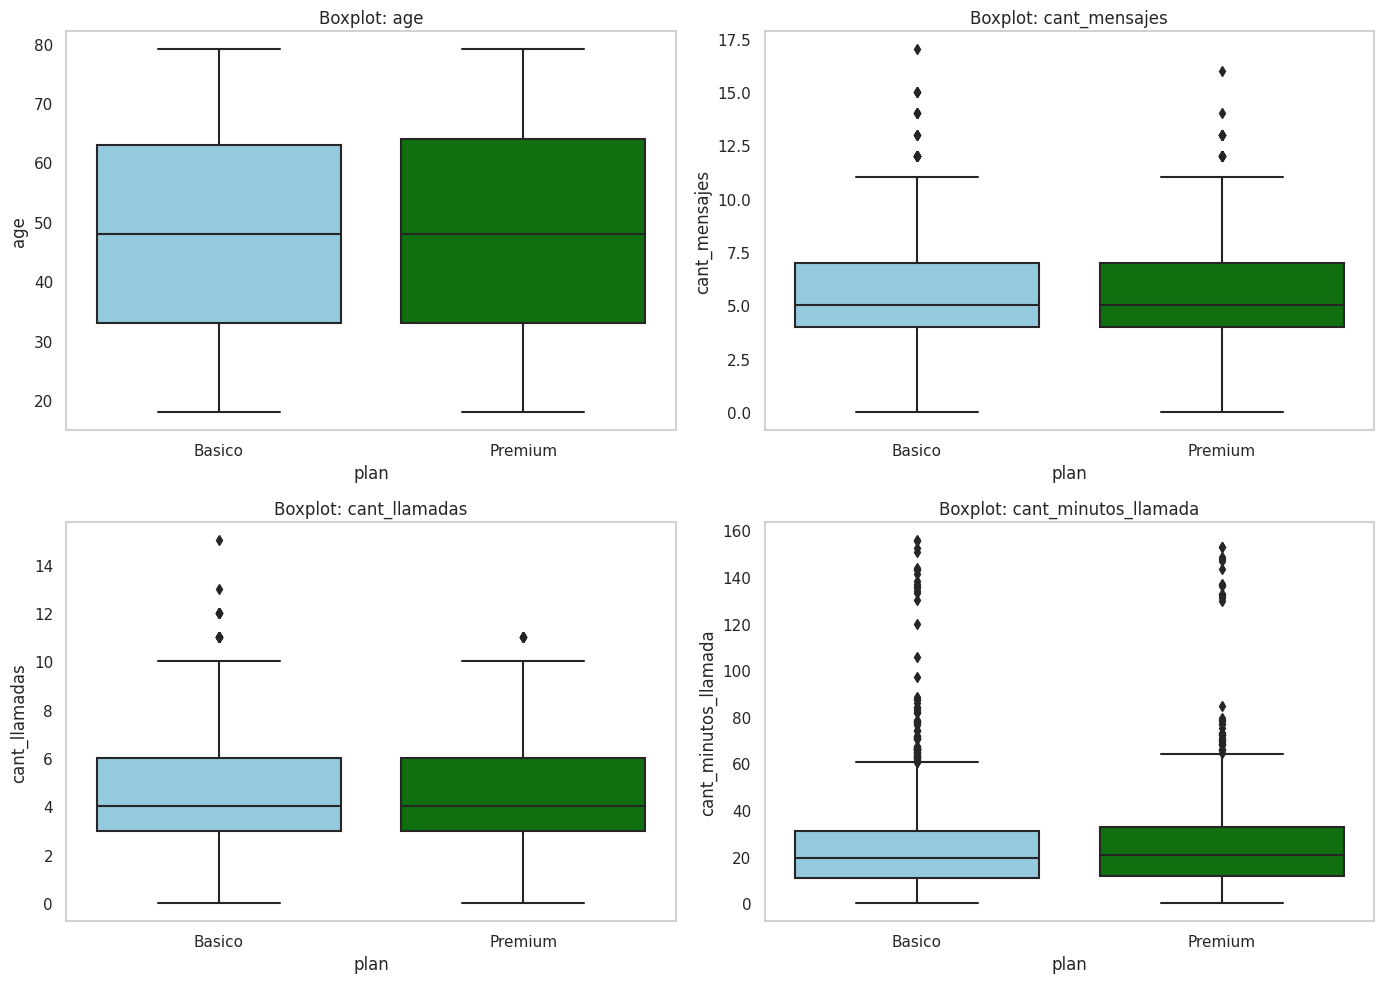

In [78]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Primero configuramos el gráfico  para generar los 4 gráficos (2 filas, 2 columnas)
plt.figure(figsize=(14, 10))

for i, col in enumerate(columnas_numericas):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=user_profile, x='plan', y=col, palette={'Basico': 'skyblue', 'Premium': 'green'})
    plt.title(f'Boxplot: {col}')
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

💡Insights: 
- Age: ...(presenta o no outliers) NO PRESENTA OUTLIERS
- cant_mensajes: ...PRESENTAN OUTLIERS HACIA ARRIBA AMBOS PLANES, DONDE CURIOSAMENTE EL PLAN BÁSICO PRESENTA MÁS QUE EL PREMIUM
- cant_llamadas: ...DE IGUAL MANERA EL PLAN BÁSICO PRESENTA MAYOR CANTIDAD DE OUTLIERS HACIA ARRIBA
- cant_minutos_llamada: ...IGUALMENTE SE REPITE EL PATRÓN DE EXISTENCIA DE OUTLIERS EN AMBOS PLANES, LIGERAMENTE MÁS CANTIDAD EN EL PLAN BÁSICO.

In [79]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
print("Análisis de Límites y Outliers (Método IQR):")
print("-" * 50)

for col in columnas_limites:
    # Calculamos los cuartiles
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Definimos el límite superior (1.5 veces el IQR por encima de Q3)
    limite_superior = Q3 + 1.5 * IQR
    
    # Identificamos cuántos registros superan ese límite
    outliers_count = (user_profile[col] > limite_superior).sum()
    
    print(f"Variable: {col}")
    print(f"  > Tercer Cuartil (Q3): {Q3:.2f}")
    print(f"  > Límite Superior: {limite_superior:.2f}")
    print(f"  > Cantidad de Outliers: {outliers_count}")
    print("-" * 50)


Análisis de Límites y Outliers (Método IQR):
--------------------------------------------------
Variable: cant_mensajes
  > Tercer Cuartil (Q3): 7.00
  > Límite Superior: 11.50
  > Cantidad de Outliers: 46
--------------------------------------------------
Variable: cant_llamadas
  > Tercer Cuartil (Q3): 6.00
  > Límite Superior: 10.50
  > Cantidad de Outliers: 30
--------------------------------------------------
Variable: cant_minutos_llamada
  > Tercer Cuartil (Q3): 31.41
  > Límite Superior: 61.87
  > Cantidad de Outliers: 109
--------------------------------------------------


In [80]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
  Sí, es recomendable mantener porque el límite superior (11.5) es extremadamente bajo; la gran mayoría de los usuarios casi no envían SMS (Q3 de 7 mensajes). Tener 17 mensajes (el máximo) es un comportamiento humano totalmente normal y eliminarlos borraría información real sobre cómo se usa el servicio de mensajería, aunque sea poco.
  
- cant_llamadas: mantener o no outliers, porqué?
  Sí también, ya que igual que con los mensajes, el límite de 10.5 llamadas es bajo debido a la alta concentración de usuarios poco activos. Un usuario que hace 15 llamadas al mes (el máximo registrado) es un cliente legítimo. Esto no representa errores del sistema, sino el segmento de usuarios con mayor actividad social.

  
- cant_minutos_llamada: mantener o no outliers, porqué?

  Sí también, ya que si bien esta es la variable más crítica para el negocio, es importante reflexionar que aparentemente 155 minutos parece mucho comparado con el promedio (23 min); pero esto es menos de 3 horas de conversación al mes.

  Estos 109 usuarios son los "clientes de alto valor"; eliminarlos ocultaría el consumo real que genera presión sobre la red y, potencialmente, los mayores ingresos por excedentes.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [81]:
# Crear columna grupo_uso
# 1. Definimos las condiciones lógicas
# Es importante el orden: de la más restrictiva a la más general
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

# 2. Definimos los nombres de los grupos correspondientes
resultados = ['Bajo uso', 'Uso medio']

# 3. Aplicamos la segmentación
# 'Alto uso' se asigna automáticamente a todo lo que no cumpla las condiciones anteriores (default)
user_profile['grupo_uso'] = np.select(condiciones, resultados, default='Alto uso')

# 4. Verificamos la distribución de los nuevos grupos
print("Distribución de usuarios por segmento de uso:")
print(user_profile['grupo_uso'].value_counts())

Distribución de usuarios por segmento de uso:
Uso medio    2943
Bajo uso      779
Alto uso      278
Name: grupo_uso, dtype: int64


In [82]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [83]:
# Crear columna grupo_edad
# 1. Definimos los rangos de edad (bins) y las etiquetas
# Rangos: 0-30 (Joven), 30-60 (Adulto), 60-100 (Adulto Mayor)
bins = [0, 30, 60, 120]
labels = ['Joven', 'Adulto', 'Adulto Mayor']

# 2. Creamos la nueva columna
user_profile['grupo_edad'] = pd.cut(user_profile['age'], bins=bins, labels=labels)

# 3. Verificamos cuántos usuarios hay en cada grupo
print("Distribución por Grupo de Edad:")
print(user_profile['grupo_edad'].value_counts())

Distribución por Grupo de Edad:
Adulto          2008
Adulto Mayor    1151
Joven            841
Name: grupo_edad, dtype: int64


In [84]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

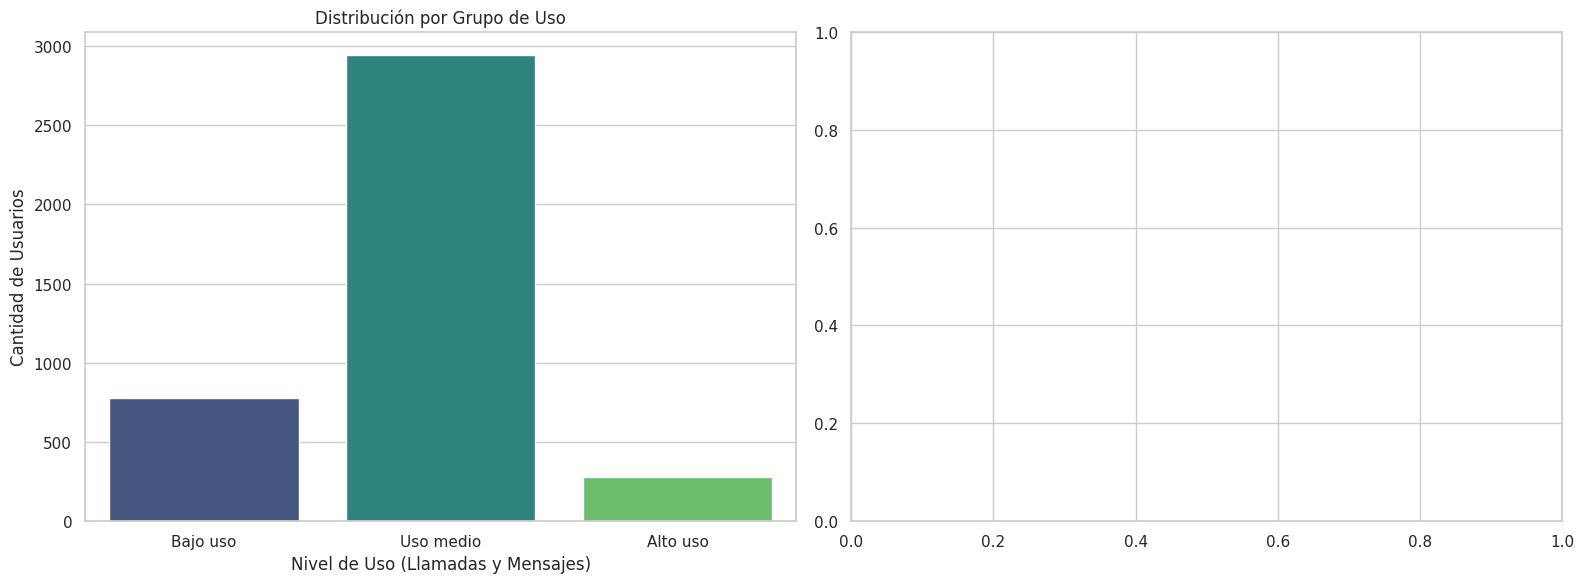

In [85]:
# Visualización de los segmentos por uso
# sns.countplot(...)
# Configuramos el área de dibujo para dos gráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico para grupo_uso
sns.countplot(data=user_profile, x='grupo_uso', ax=axes[0], palette='viridis', 
              order=['Bajo uso', 'Uso medio', 'Alto uso'])
axes[0].set_title('Distribución por Grupo de Uso')
axes[0].set_xlabel('Nivel de Uso (Llamadas y Mensajes)')
axes[0].set_ylabel('Cantidad de Usuarios')
plt.tight_layout()
plt.show()

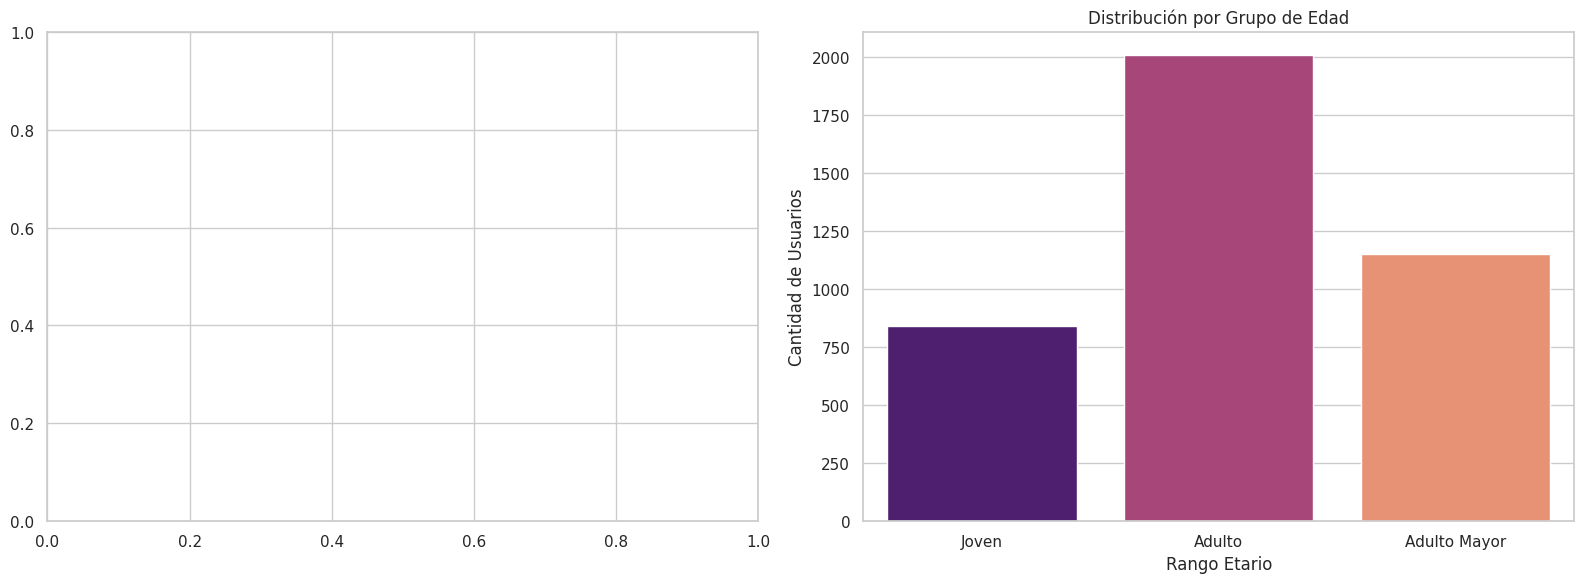

In [87]:
# Visualización de los segmentos por edad
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(data=user_profile, x='grupo_edad', ax=axes[1], palette='magma',
              order=['Joven', 'Adulto', 'Adulto Mayor'])
axes[1].set_title('Distribución por Grupo de Edad')
axes[1].set_xlabel('Rango Etario')
axes[1].set_ylabel('Cantidad de Usuarios')

plt.tight_layout()
plt.show()


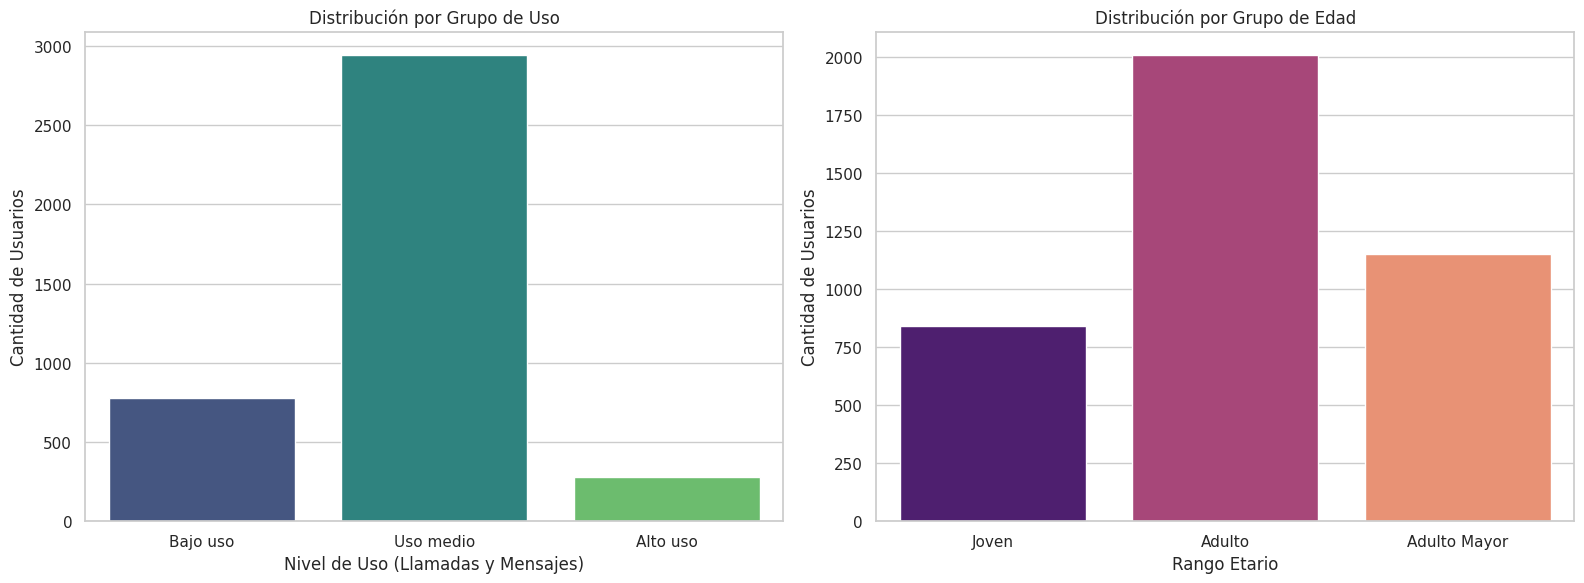

In [88]:
# Ahora muestro las dos gráficas juntas que nos permiten tener una mejor visión e interpretación
# Configuramos el área de dibujo para dos gráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico para grupo_uso
sns.countplot(data=user_profile, x='grupo_uso', ax=axes[0], palette='viridis', 
              order=['Bajo uso', 'Uso medio', 'Alto uso'])
axes[0].set_title('Distribución por Grupo de Uso')
axes[0].set_xlabel('Nivel de Uso (Llamadas y Mensajes)')
axes[0].set_ylabel('Cantidad de Usuarios')

# 2. Gráfico para grupo_edad
sns.countplot(data=user_profile, x='grupo_edad', ax=axes[1], palette='magma',
              order=['Joven', 'Adulto', 'Adulto Mayor'])
axes[1].set_title('Distribución por Grupo de Edad')
axes[1].set_xlabel('Rango Etario')
axes[1].set_ylabel('Cantidad de Usuarios')

plt.tight_layout()
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Originalmente, el dataset presentaba inconsistencias que podían sesgar los resultados. Los puntos clave fueron:

  -- Valores Centinela en Edad: Se detectaron registros con la edad -999. Aunque representaban un porcentaje bajo (menor al 2% de la muestra), se corrigieron mediante la imputación por mediana para evitar que el promedio de edad cayera artificialmente.

  -- Datos Nulos "Disfrazados": En la columna de ciudad, se identificaron signos de interrogación ('?') que no eran reconocidos como nulos por Python. Se estandarizaron a pd.NA para permitir un conteo real de la falta de información geográfica.

  -- Se detectaron 40 registros con fecha del año 2026, cuando el año máximo del datset debería de ser del año 2024. En este caso se marcaron como nulas (pd.NA) las fechas fuera de rango.


🔍 **Segmentos por Edad**
- Identificamos una base de clientes madura y consolidada:

    Adultos (2008 usuarios): Es el corazón de ConnectaTel (50% de la base). Es el segmento con mayor estabilidad financiera y uso constante de voz.

    Adultos Mayores (1151 usuarios): Un grupo sorprendentemente grande (29%). Su comportamiento suele estar más orientado a llamadas de larga duración que a mensajería masiva.

    Jóvenes (841 usuarios): El segmento más pequeño (21%). Representan el futuro del negocio, pero actualmente tienen un peso menor en la infraestructura de voz. 


📊 **Segmentos por Nivel de Uso**
- La actividad se distribuye de la siguiente manera:

  -- Uso Medio (2943 usuarios): El 73% de tus clientes. Son usuarios que no generan alertas por exceso, pero que definen la carga operativa de la red.

  -- Bajo Uso (779 usuarios): Clientes con riesgo de abandono (churn) o que utilizan el servicio solo para emergencias.

 -- Alto Uso (278 usuarios): El 7% de la base. Este pequeño grupo es el que genera los mayores ingresos por excedentes o el que más aprovecha el plan Premium.


➡️ Esto sugiere que ...
La empresa depende de una masa crítica de Adultos con Uso Medio. Sin embargo, los 278 usuarios de Alto Uso y los 109 outliers de minutos identificados previamente son los que "rompen" la norma. Dado que el 75% de los usuarios consume menos de 31 minutos, aquellos que llegan a los 155 minutos están en una categoría de valor totalmente distinta que debe ser protegida.


💡 **Recomendaciones**
1. Protección del "Power User": Los 278 usuarios de Alto Uso son los más propensos a ser "robados" por la competencia con ofertas ilimitadas. Se recomienda un análisis más detallado y profundo: si están en el plan Básico, ofrecerles un paso al Premium con un descuento por lealtad para evitar que su factura alta los frustre.

2. Optimización para Adultos Mayores: Con 1,151 usuarios en este rango, ConnectaTel podría lanzar un plan de "Cercanía" que priorice minutos de llamadas sobre mensajes o datos, ajustándose a su patrón de uso real.

3. Activación del Segmento Joven: Al ser el grupo más pequeño, se requieren paquetes "Add-on" de mensajería o redes sociales que no dependan del conteo de llamadas, buscando atraer a un público que hoy prefiere no usar el teléfono para hablar.

4. Ajuste de Límites en Plan Básico: Dado que el límite superior de "uso normal" es de 62 minutos, cualquier plan básico debería estar cerca de este umbral para evitar que el 73% de los usuarios (Uso Medio) perciba cobros inesperados, lo cual mejora la satisfacción general.

CONCLUSIÓN FINAL:
ConnectaTel es una empresa de 'Adultos de Uso Moderado'. Nuestra oportunidad no está en atraer a millones de jóvenes, sino en asegurar que nuestros 278 usuarios de Alto Uso no se fuguen y en ofrecer un plan más robusto a los 2,008 adultos que hoy sostienen la operación.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`